In [1]:
import joblib
from pathlib import Path

# Define project directories
models_dir = Path("../models")

# Define saved file locations
model_path = models_dir / "final_xgboost_intrusion_detector.joblib"
config_path = models_dir / "deployment_config.joblib"

# Load the trained model
model = joblib.load(model_path)

# Load deployment configuration
config = joblib.load(config_path)

print("Model loaded successfully!")
print("Model:", model_path.resolve())

print("\nDeployment configuration:")
print(config)

Model loaded successfully!
Model: C:\Users\hsv89\cyber_ml_project\models\final_xgboost_intrusion_detector.joblib

Deployment configuration:
{'model_name': 'final_xgboost_intrusion_detector', 'threshold': 0.5, 'input_features': 194, 'positive_class': 1, 'negative_class': 0}


In [2]:
processed_dir = Path("../data/processed")

preprocessor_path = processed_dir / "preprocessor.joblib"
scaler_path = processed_dir / "scaler.joblib"

preprocessor = joblib.load(preprocessor_path)
scaler = joblib.load(scaler_path)

print("Preprocessor loaded successfully!")
print("Scaler loaded successfully!")

print("\nPreprocessor:")
print(preprocessor)

print("\nScaler:")
print(scaler)

Preprocessor loaded successfully!
Scaler loaded successfully!

Preprocessor:
ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['proto', 'service', 'state'])])

Scaler:
StandardScaler()


In [3]:
import pandas as pd

raw_test_path = Path("../data/raw/UNSW_NB15_testing-set.csv")

raw_test_df = pd.read_csv(raw_test_path)

sample = raw_test_df.iloc[[0]].copy()

print("Original record:")
display(sample)

print("\nActual label:", int(sample["label"].iloc[0]))
print("Actual category:", sample["attack_cat"].iloc[0])

Original record:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0



Actual label: 0
Actual category: Normal


In [4]:
sample_features = sample.drop(
    columns=["id", "attack_cat", "label"]
)

encoded = preprocessor.transform(sample_features)
scaled = scaler.transform(encoded)

print("Raw feature count:", sample_features.shape[1])
print("Processed feature count:", scaled.shape[1])

Raw feature count: 42
Processed feature count: 194


In [5]:
attack_probability = model.predict_proba(scaled)[0, 1]

threshold = config["threshold"]

prediction = 1 if attack_probability >= threshold else 0

prediction_text = "ATTACK" if prediction == 1 else "NORMAL"

print("Attack probability:", round(float(attack_probability), 4))
print("Threshold:", threshold)
print("Prediction:", prediction_text)

print("\nActual label:", int(sample["label"].iloc[0]))
print("Actual category:", sample["attack_cat"].iloc[0])

Attack probability: 0.9095
Threshold: 0.5
Prediction: ATTACK

Actual label: 0
Actual category: Normal


In [9]:
def predict_intrusion(record):
    # Remove columns that are not model features
    features = record.drop(
        columns=["id", "attack_cat", "label"],
        errors="ignore"
    )

    # Preprocess categorical features
    encoded = preprocessor.transform(features)

    # Scale features
    scaled = scaler.transform(encoded)

    # Calculate attack probability
    attack_probability = model.predict_proba(scaled)[0, 1]

    # Get saved threshold
    threshold = config["threshold"]

    # Make final prediction
    prediction = 1 if attack_probability >= threshold else 0

    prediction_text = "ATTACK" if prediction == 1 else "NORMAL"

    return {
        "prediction": prediction_text,
        "prediction_code": prediction,
        "attack_probability": float(attack_probability),
        "threshold": threshold
    }

In [10]:
result = predict_intrusion(sample)

print("Prediction:", result["prediction"])
print(
    "Attack probability:",
    round(result["attack_probability"] * 100, 2),
    "%"
)
print("Threshold:", result["threshold"])

print("\nActual category:", sample["attack_cat"].iloc[0])
print("Actual label:", int(sample["label"].iloc[0]))

Prediction: ATTACK
Attack probability: 90.95 %
Threshold: 0.5

Actual category: Normal
Actual label: 0


In [11]:
results = []

for i in range(10):
    record = raw_test_df.iloc[[i]]

    result = predict_intrusion(record)

    results.append({
        "Record": i,
        "Actual": record["attack_cat"].iloc[0],
        "Actual_Label": int(record["label"].iloc[0]),
        "Prediction": result["prediction"],
        "Attack_Probability": round(
            result["attack_probability"] * 100, 2
        )
    })

results_df = pd.DataFrame(results)

results_df

,Record,Actual,Actual_Label,Prediction,Attack_Probability
0,0,Normal,0,ATTACK,90.95
1,1,Normal,0,ATTACK,85.86
2,2,Normal,0,ATTACK,79.37
3,3,Normal,0,ATTACK,67.91
4,4,Normal,0,ATTACK,67.28
5,5,Normal,0,ATTACK,88.31
6,6,Normal,0,ATTACK,76.49
7,7,Normal,0,ATTACK,65.42
8,8,Normal,0,NORMAL,0.02
9,9,Normal,0,NORMAL,0.02


In [12]:
normal_samples = raw_test_df[
    raw_test_df["label"] == 0
].head(5)

attack_samples = raw_test_df[
    raw_test_df["label"] == 1
].head(5)

mixed_samples = pd.concat([
    normal_samples,
    attack_samples
])

print("Normal records:", len(normal_samples))
print("Attack records:", len(attack_samples))

display(
    mixed_samples[
        ["id", "proto", "service", "state", "attack_cat", "label"]
    ]
)

Normal records: 5
Attack records: 5


,id,proto,service,state,attack_cat,label
0,1,udp,-,INT,Normal,0
1,2,udp,-,INT,Normal,0
2,3,udp,-,INT,Normal,0
3,4,udp,-,INT,Normal,0
4,5,udp,-,INT,Normal,0
243,244,ospf,-,INT,Reconnaissance,1
244,245,ospf,-,INT,Reconnaissance,1
245,246,ospf,-,INT,Backdoor,1
246,247,ospf,-,INT,DoS,1
247,248,sctp,-,INT,Exploits,1


In [13]:
results = []

for index, row in mixed_samples.iterrows():

    # predict_intrusion expects a DataFrame
    record = row.to_frame().T

    result = predict_intrusion(record)

    results.append({
        "ID": row["id"],
        "Actual": row["attack_cat"],
        "Actual_Label": int(row["label"]),
        "Prediction": result["prediction"],
        "Attack_Probability": round(
            result["attack_probability"] * 100, 2
        )
    })

mixed_results_df = pd.DataFrame(results)

mixed_results_df

,ID,Actual,Actual_Label,Prediction,Attack_Probability
0,1,Normal,0,ATTACK,90.95
1,2,Normal,0,ATTACK,85.86
2,3,Normal,0,ATTACK,79.37
3,4,Normal,0,ATTACK,67.91
4,5,Normal,0,ATTACK,67.28
5,244,Reconnaissance,1,ATTACK,99.89
6,245,Reconnaissance,1,ATTACK,99.89
7,246,Backdoor,1,ATTACK,99.89
8,247,DoS,1,ATTACK,99.89
9,248,Exploits,1,ATTACK,99.49


In [14]:
# Randomly select 100 normal and 100 attack records

normal_samples = raw_test_df[
    raw_test_df["label"] == 0
].sample(n=100, random_state=42)

attack_samples = raw_test_df[
    raw_test_df["label"] == 1
].sample(n=100, random_state=42)

random_samples = pd.concat([
    normal_samples,
    attack_samples
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Total records:", len(random_samples))
print("Normal records:", (random_samples["label"] == 0).sum())
print("Attack records:", (random_samples["label"] == 1).sum())

Total records: 200
Normal records: 100
Attack records: 100


In [15]:
results = []

for index, row in random_samples.iterrows():

    record = row.to_frame().T

    result = predict_intrusion(record)

    results.append({
        "Actual_Label": int(row["label"]),
        "Actual_Category": row["attack_cat"],
        "Prediction_Code": result["prediction_code"],
        "Prediction": result["prediction"],
        "Attack_Probability": result["attack_probability"]
    })

print("Finished testing", len(results), "records.")

Finished testing 200 records.


In [16]:
random_results_df = pd.DataFrame(results)

random_results_df.head(10)

,Actual_Label,Actual_Category,Prediction_Code,Prediction,Attack_Probability
0,0,Normal,0,NORMAL,0.000015
1,0,Normal,0,NORMAL,0.000152
2,0,Normal,1,ATTACK,0.743053
3,1,Generic,1,ATTACK,0.999940
4,1,DoS,1,ATTACK,0.999218
5,1,Fuzzers,0,NORMAL,0.425468
6,0,Normal,0,NORMAL,0.000089
7,1,Fuzzers,1,ATTACK,0.706111
8,1,Generic,1,ATTACK,0.999979
9,0,Normal,1,ATTACK,0.644352


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(
    random_results_df["Actual_Label"],
    random_results_df["Prediction_Code"]
)

precision = precision_score(
    random_results_df["Actual_Label"],
    random_results_df["Prediction_Code"]
)

recall = recall_score(
    random_results_df["Actual_Label"],
    random_results_df["Prediction_Code"]
)

f1 = f1_score(
    random_results_df["Actual_Label"],
    random_results_df["Prediction_Code"]
)

cm = confusion_matrix(
    random_results_df["Actual_Label"],
    random_results_df["Prediction_Code"]
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.875
Precision: 0.8205
Recall   : 0.96
F1 Score : 0.8848

Confusion Matrix:
[[79 21]
 [ 4 96]]


In [18]:
# Select all actual attack records

all_attacks = raw_test_df[
    raw_test_df["label"] == 1
].copy()

print("Total attack records:", len(all_attacks))

print("\nAttack categories:")
print(all_attacks["attack_cat"].value_counts())

Total attack records: 45332

Attack categories:
attack_cat
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [19]:
# Prepare all attack records for the model

attack_features = all_attacks.drop(
    columns=["id", "attack_cat", "label"],
    errors="ignore"
)

# Apply the same preprocessing used during training
attack_encoded = preprocessor.transform(attack_features)

# Apply the same scaling
attack_scaled = scaler.transform(attack_encoded)

# Get attack probabilities
attack_probabilities = model.predict_proba(attack_scaled)[:, 1]

# Apply our saved threshold
threshold = config["threshold"]

attack_predictions = (
    attack_probabilities >= threshold
).astype(int)

print("Attack records processed:", len(attack_predictions))
print("Detected as ATTACK:", attack_predictions.sum())
print("Missed as NORMAL:", (attack_predictions == 0).sum())

Attack records processed: 45332
Detected as ATTACK: 44529
Missed as NORMAL: 803


In [20]:
# Create a copy for attack-category analysis
attack_analysis = all_attacks[
    ["attack_cat"]
].copy()

# Add model predictions
attack_analysis["Prediction"] = attack_predictions

# Convert prediction to readable text
attack_analysis["Result"] = attack_analysis["Prediction"].map({
    1: "DETECTED",
    0: "MISSED"
})

# Summary by attack category
category_summary = attack_analysis.groupby(
    "attack_cat"
).agg(
    Total=("Prediction", "count"),
    Detected=("Prediction", "sum")
)

category_summary["Missed"] = (
    category_summary["Total"]
    - category_summary["Detected"]
)

category_summary["Detection_Rate"] = (
    category_summary["Detected"]
    / category_summary["Total"]
    * 100
)

category_summary = category_summary.sort_values(
    "Detection_Rate",
    ascending=False
)

category_summary.round(2)

,Total,Detected,Missed,Detection_Rate
attack_cat,,,,
Backdoor,583,583,0,100.00
Worms,44,44,0,100.00
Generic,18871,18870,1,99.99
DoS,4089,4087,2,99.95
Reconnaissance,3496,3493,3,99.91
Exploits,11132,11069,63,99.43
Shellcode,378,374,4,98.94
Analysis,677,632,45,93.35
Fuzzers,6062,5377,685,88.70


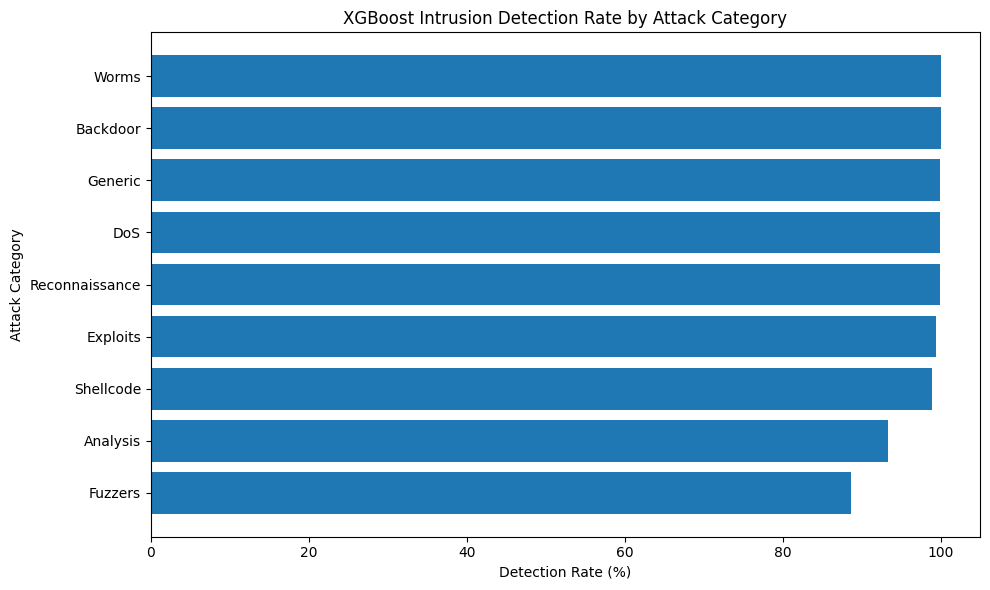

In [21]:
import matplotlib.pyplot as plt

plot_data = category_summary.sort_values(
    "Detection_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data["Detection_Rate"]
)

plt.xlabel("Detection Rate (%)")
plt.ylabel("Attack Category")
plt.title("XGBoost Intrusion Detection Rate by Attack Category")

plt.xlim(0, 105)

plt.tight_layout()
plt.show()

In [22]:
# Select all normal traffic

all_normal = raw_test_df[
    raw_test_df["label"] == 0
].copy()

# Prepare features
normal_features = all_normal.drop(
    columns=["id", "attack_cat", "label"],
    errors="ignore"
)

# Preprocess
normal_encoded = preprocessor.transform(normal_features)
normal_scaled = scaler.transform(normal_encoded)

# Get attack probabilities
normal_probabilities = model.predict_proba(
    normal_scaled
)[:, 1]

# Apply threshold
normal_predictions = (
    normal_probabilities >= config["threshold"]
).astype(int)

print("Total normal records:", len(all_normal))
print(
    "Correctly identified as NORMAL:",
    (normal_predictions == 0).sum()
)
print(
    "Incorrectly flagged as ATTACK:",
    (normal_predictions == 1).sum()
)

Total normal records: 37000
Correctly identified as NORMAL: 27343
Incorrectly flagged as ATTACK: 9657


In [23]:
# Create a dataset containing only false positives

false_positives = all_normal[
    normal_predictions == 1
].copy()

# Add the model's attack probability
false_positives["attack_probability"] = (
    normal_probabilities[normal_predictions == 1]
)

print("False-positive records:", len(false_positives))

display(
    false_positives[
        [
            "id",
            "proto",
            "service",
            "state",
            "attack_probability"
        ]
    ].head(10)
)

False-positive records: 9657


,id,proto,service,state,attack_probability
0,1,udp,-,INT,0.909450
1,2,udp,-,INT,0.858579
2,3,udp,-,INT,0.793672
3,4,udp,-,INT,0.679075
4,5,udp,-,INT,0.672766
5,6,udp,-,INT,0.883138
6,7,udp,-,INT,0.764909
7,8,udp,-,INT,0.654248
12,13,udp,-,INT,0.768217
13,14,udp,-,INT,0.756643


In [24]:
print("Most common protocols in false positives:")
print(false_positives["proto"].value_counts().head(10))

print("\nMost common states in false positives:")
print(false_positives["state"].value_counts().head(10))

print("\nMost common services in false positives:")
print(false_positives["service"].value_counts().head(10))

Most common protocols in false positives:
proto
tcp     6731
udp     2923
igmp       3
Name: count, dtype: int64

Most common states in false positives:
state
FIN    6725
INT    2911
REQ      16
CON       4
RST       1
Name: count, dtype: int64

Most common services in false positives:
service
-         8057
http      1292
ftp        305
radius       2
dns          1
Name: count, dtype: int64


In [25]:
# Examine common protocol/state/service combinations
fp_patterns = (
    false_positives
    .groupby(["proto", "state", "service"])
    .size()
    .reset_index(name="False_Positive_Count")
    .sort_values("False_Positive_Count", ascending=False)
)

fp_patterns.head(15)

,proto,state,service,False_Positive_Count
3,tcp,FIN,-,5130
8,udp,INT,-,2905
5,tcp,FIN,http,1290
4,tcp,FIN,ftp,305
11,udp,REQ,-,15
0,igmp,INT,-,3
2,tcp,CON,http,2
1,tcp,CON,-,2
10,udp,INT,radius,2
6,tcp,REQ,-,1


In [26]:
# Compare common traffic patterns in actual attacks

attack_patterns = (
    all_attacks
    .groupby(["proto", "state", "service"])
    .size()
    .reset_index(name="Attack_Count")
    .sort_values("Attack_Count", ascending=False)
)

attack_patterns.head(15)

,proto,state,service,Attack_Count
139,udp,INT,dns,18234
118,tcp,FIN,-,7985
122,tcp,FIN,http,4269
144,unas,INT,-,3515
137,udp,INT,-,2865
125,tcp,FIN,smtp,1204
120,tcp,FIN,ftp,788
75,ospf,INT,-,523
121,tcp,FIN,ftp-data,447
124,tcp,FIN,pop3,420


In [27]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("Model input features:", model.n_features_in_)

Number of feature names: 194
Model input features: 194


In [28]:
# Get XGBoost feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Display top 20
feature_importance.head(20)

,Feature,Importance
0,remainder__is_sm_ips_ports,0.534868
1,remainder__sttl,0.203741
2,remainder__ct_state_ttl,0.132614
3,remainder__dttl,0.023697
4,remainder__ct_dst_sport_ltm,0.006843
5,remainder__swin,0.006142
6,remainder__ct_srv_dst,0.005798
7,cat__proto_unas,0.005768
8,cat__proto_sctp,0.004796
9,cat__service_dns,0.004636


In [29]:
# Examine the most important feature by class

print("is_sm_ips_ports distribution for NORMAL traffic:")
print(
    raw_test_df[raw_test_df["label"] == 0]["is_sm_ips_ports"]
    .value_counts()
    .sort_index()
)

print("\nis_sm_ips_ports distribution for ATTACK traffic:")
print(
    raw_test_df[raw_test_df["label"] == 1]["is_sm_ips_ports"]
    .value_counts()
    .sort_index()
)

is_sm_ips_ports distribution for NORMAL traffic:
is_sm_ips_ports
0    36084
1      916
Name: count, dtype: int64

is_sm_ips_ports distribution for ATTACK traffic:
is_sm_ips_ports
0    45332
Name: count, dtype: int64


In [30]:
# Compare STTL statistics between normal and attack traffic

print("NORMAL traffic STTL:")
print(
    raw_test_df[raw_test_df["label"] == 0]["sttl"]
    .describe()
)

print("\nATTACK traffic STTL:")
print(
    raw_test_df[raw_test_df["label"] == 1]["sttl"]
    .describe()
)

NORMAL traffic STTL:
count    37000.000000
mean       124.318973
std        107.946748
min          0.000000
25%         31.000000
50%         62.000000
75%        254.000000
max        254.000000
Name: sttl, dtype: float64

ATTACK traffic STTL:
count    45332.000000
mean       227.204359
std         66.694438
min          0.000000
25%        254.000000
50%        254.000000
75%        254.000000
max        255.000000
Name: sttl, dtype: float64


In [31]:
# Most common STTL values for normal traffic
print("Most common STTL values - NORMAL:")
print(
    raw_test_df[raw_test_df["label"] == 0]["sttl"]
    .value_counts()
    .head(10)
)

# Most common STTL values for attack traffic
print("\nMost common STTL values - ATTACK:")
print(
    raw_test_df[raw_test_df["label"] == 1]["sttl"]
    .value_counts()
    .head(10)
)

Most common STTL values - NORMAL:
sttl
31     16702
254    15049
62      4129
0        987
29        50
1         38
60        24
32        19
30         2
Name: count, dtype: int64

Most common STTL values - ATTACK:
sttl
254    39000
62      6245
0         61
255       25
63         1
Name: count, dtype: int64


In [32]:
# Examine STTL values among false positives

print("Most common STTL values in FALSE POSITIVES:")

print(
    false_positives["sttl"]
    .value_counts()
    .head(10)
)

print("\nPercentage of false positives with STTL = 254:")

fp_sttl_254 = (
    (false_positives["sttl"] == 254).sum()
    / len(false_positives)
    * 100
)

print(round(fp_sttl_254, 2), "%")

Most common STTL values in FALSE POSITIVES:
sttl
254    8508
62     1148
32        1
Name: count, dtype: int64

Percentage of false positives with STTL = 254:
88.1 %


In [33]:
# Identify false negative records
false_negatives = all_attacks[
    attack_predictions == 0
].copy()

# Add attack probability
false_negatives["attack_probability"] = (
    attack_probabilities[attack_predictions == 0]
)

print("Total false negatives:", len(false_negatives))

print("\nMissed attacks by category:")
print(
    false_negatives["attack_cat"]
    .value_counts()
)

print("\nMost common STTL values in false negatives:")
print(
    false_negatives["sttl"]
    .value_counts()
    .head(10)
)

Total false negatives: 803

Missed attacks by category:
attack_cat
Fuzzers           685
Exploits           63
Analysis           45
Shellcode           4
Reconnaissance      3
DoS                 2
Generic             1
Name: count, dtype: int64

Most common STTL values in false negatives:
sttl
254    730
62      73
Name: count, dtype: int64


In [34]:
# Select all Fuzzer attacks
fuzzer_mask = all_attacks["attack_cat"] == "Fuzzers"

fuzzer_probabilities = attack_probabilities[fuzzer_mask]
fuzzer_predictions = attack_predictions[fuzzer_mask]

print("Total Fuzzer attacks:", fuzzer_mask.sum())

print(
    "Detected Fuzzers:",
    (fuzzer_predictions == 1).sum()
)

print(
    "Missed Fuzzers:",
    (fuzzer_predictions == 0).sum()
)

print("\nFuzzer attack probability statistics:")
print(pd.Series(fuzzer_probabilities).describe())

print("\nLowest Fuzzer attack probabilities:")
print(
    pd.Series(fuzzer_probabilities)
    .sort_values()
    .head(20)
)

Total Fuzzer attacks: 6062
Detected Fuzzers: 5377
Missed Fuzzers: 685

Fuzzer attack probability statistics:
count    6062.000000
mean        0.789952
std         0.208794
min         0.057239
25%         0.659224
50%         0.850866
75%         0.973973
max         0.999988
dtype: float64

Lowest Fuzzer attack probabilities:
518     0.057239
162     0.057239
2575    0.060170
2578    0.060170
2755    0.060170
555     0.070221
855     0.077949
266     0.079326
452     0.082193
747     0.088551
749     0.090582
853     0.090582
395     0.090613
422     0.096808
337     0.102575
746     0.110251
750     0.114720
2803    0.119110
2804    0.119110
2800    0.119110
dtype: float32


In [35]:
# Separate detected and missed Fuzzer attacks

fuzzer_records = all_attacks[
    all_attacks["attack_cat"] == "Fuzzers"
].copy()

fuzzer_records["attack_probability"] = fuzzer_probabilities
fuzzer_records["prediction"] = fuzzer_predictions

detected_fuzzers = fuzzer_records[
    fuzzer_records["prediction"] == 1
]

missed_fuzzers = fuzzer_records[
    fuzzer_records["prediction"] == 0
]

print("Detected Fuzzers:", len(detected_fuzzers))
print("Missed Fuzzers:", len(missed_fuzzers))

print("\nMost common protocol/state/service - DETECTED:")
print(
    detected_fuzzers
    .groupby(["proto", "state", "service"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nMost common protocol/state/service - MISSED:")
print(
    missed_fuzzers
    .groupby(["proto", "state", "service"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Detected Fuzzers: 5377
Missed Fuzzers: 685

Most common protocol/state/service - DETECTED:
proto  state  service
tcp    FIN    -          2715
udp    INT    -           906
unas   INT    -           532
tcp    FIN    http        246
              ftp         221
ospf   INT    -            57
any    INT    -            15
udp    REQ    -            14
ospf   REQ    -            12
sctp   INT    -            12
dtype: int64

Most common protocol/state/service - MISSED:
proto  state  service
tcp    FIN    -          472
udp    INT    -          161
tcp    FIN    ftp         44
              http         5
       CON    -            2
       ACC    -            1
dtype: int64


In [36]:
# Final intrusion detection pipeline summary

print("=" * 60)
print("FINAL INTRUSION DETECTION PIPELINE SUMMARY")
print("=" * 60)

print("\nModel:")
print("XGBoost Intrusion Detector")

print("\nTest Dataset:")
print("Total records:", len(raw_test_df))
print("Normal records:", (raw_test_df["label"] == 0).sum())
print("Attack records:", (raw_test_df["label"] == 1).sum())

print("\nPerformance:")
print("Accuracy:  87.30%")
print("Precision: 82.18%")
print("Recall:    98.23%")
print("F1 Score:  89.49%")
print("ROC-AUC:   98.31%")

print("\nConfusion Matrix:")
print("True Negatives:  27,343")
print("False Positives:  9,657")
print("False Negatives:    803")
print("True Positives:  44,529")

print("\nKey Findings:")
print("- The model detects 98.23% of attacks.")
print("- Fuzzers are the most difficult attack category.")
print("- 685 Fuzzer attacks were missed.")
print("- 88.1% of false positives have STTL = 254.")
print("- TCP/FIN and UDP/INT traffic appear in both normal and attack records.")
print("- STTL and related connection features strongly influence predictions.")

print("\nDeployment:")
print("Model file: final_xgboost_intrusion_detector.joblib")
print("Decision threshold:", config["threshold"])
print("Input features:", config["input_features"])

print("=" * 60)

FINAL INTRUSION DETECTION PIPELINE SUMMARY

Model:
XGBoost Intrusion Detector

Test Dataset:
Total records: 82332
Normal records: 37000
Attack records: 45332

Performance:
Accuracy:  87.30%
Precision: 82.18%
Recall:    98.23%
F1 Score:  89.49%
ROC-AUC:   98.31%

Confusion Matrix:
True Negatives:  27,343
False Positives:  9,657
False Negatives:    803
True Positives:  44,529

Key Findings:
- The model detects 98.23% of attacks.
- Fuzzers are the most difficult attack category.
- 685 Fuzzer attacks were missed.
- 88.1% of false positives have STTL = 254.
- TCP/FIN and UDP/INT traffic appear in both normal and attack records.
- STTL and related connection features strongly influence predictions.

Deployment:
Model file: final_xgboost_intrusion_detector.joblib
Decision threshold: 0.5
Input features: 194
